# **STEP 0: Imports and setup**



In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, IsolationForest, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

DATA_PATH = "/content/car_insurance_premium_dataset.csv"
BASE_DATE = "2026-03-01 09:00:00"
SHIFT_DATE = "2026-04-01 09:00:00"

# **STEP 1: Load and clean the base dataset**

In [2]:
# Read the raw dataset, standardise column names, and create a unique customer identifier.
df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("/", "_", regex=False)
)

df = df.rename(columns={
    "annual_mileage_x1000_km": "annual_mileage",
    "car_manufacturing_year": "car_year",
    "insurance_premium_": "premium",
})

df["customer_id"] = np.arange(1, len(df) + 1)

print("Dataset loaded:", df.shape)
print(df.columns.tolist())


Dataset loaded: (1000, 8)
['driver_age', 'driver_experience', 'previous_accidents', 'annual_mileage', 'car_year', 'car_age', 'premium', 'customer_id']


# **STEP 2: Define helper functions**

In [3]:
# These helper utilities support the simulation and modelling process.
# Includes:
# - Age band categorisation
# - Driver age/experience consistency checks
# - Premium calculation logic
# - Quote journey simulation utilities
# - Feature engineering helpers

def age_band(age: float) -> str:
    if age < 25:
        return "17-24_high"
    if age < 40:
        return "25-39_medium"
    if age < 65:
        return "40-64_lower"
    return "65+_moderate"


def age_band_code(age: float) -> int:
    if age < 25:
        return 3
    if age < 40:
        return 2
    if age < 65:
        return 1
    return 2


def years_since_legal_driving_age(age: float) -> int:
    return max(int(round(age - 17)), 0)


def consistency_margin(age: float, experience: float) -> float:
    return years_since_legal_driving_age(age) - experience


def has_consistency_violation(age: float, experience: float) -> int:
    return int(experience > years_since_legal_driving_age(age))


def small_age_edit(curr_age: int, suspicious: bool) -> int:
    """
    Small plausible edits only.
    Suspicious users are slightly more likely to cross rating boundaries.
    """
    options = [curr_age, curr_age - 1, curr_age + 1]

    if suspicious:
        if curr_age == 24:
            return int(np.random.choice([24, 25], p=[0.40, 0.60]))
        if curr_age == 39:
            return int(np.random.choice([39, 40], p=[0.40, 0.60]))
        if curr_age == 65:
            return int(np.random.choice([65, 64], p=[0.60, 0.40]))

    new_age = int(np.random.choice(options))
    return int(np.clip(new_age, 18, 80))


def calculate_simulated_premium(age, experience, accidents, mileage, car_age):
    premium = 420.0

    if age < 25:
        premium += 340
    elif age < 40:
        premium += 150
    elif age < 65:
        premium += 70
    else:
        premium += 130

    premium += max(0, 120 - 10 * min(experience, 12))
    premium += accidents * 165
    premium += max(0, mileage - 8) * 18
    premium += max(car_age, 0) * 7

    if has_consistency_violation(age, experience):
        premium += 180

    premium += np.random.normal(0, 45)
    return round(max(premium, 250), 2)


def choose_quote_count(latent_type: int, shifted: bool = False) -> int:
    if shifted:
        if latent_type == 1:
            return np.random.choice([2, 3, 4, 5, 6], p=[0.16, 0.24, 0.24, 0.22, 0.14])
        return np.random.choice([1, 2, 3, 4, 5], p=[0.18, 0.28, 0.26, 0.18, 0.10])

    if latent_type == 1:
        return np.random.choice([2, 3, 4, 5, 6], p=[0.18, 0.26, 0.24, 0.20, 0.12])
    return np.random.choice([1, 2, 3, 4, 5], p=[0.22, 0.30, 0.24, 0.16, 0.08])


def choose_gap_minutes(latent_type: int, shifted: bool = False) -> int:
    if shifted:
        if latent_type == 1:
            return int(np.random.randint(8, 220))
        return int(np.random.randint(20, 320))

    if latent_type == 1:
        return int(np.random.randint(10, 260))
    return int(np.random.randint(25, 420))


def simulate_quote_journey(row, shifted: bool = False):
    """
    Latent customer type influences behaviour, but final suspicious label
    is determined later from the realised journey.
    """
    customer_id = int(row["customer_id"])
    latent_type = np.random.choice([0, 1], p=[0.78, 0.22])
    n_quotes = choose_quote_count(latent_type, shifted=shifted)

    if shifted:
        suspicious_mileage_bias = 0.45
        suspicious_accident_bias = 0.50
        suspicious_experience_bias = 0.46
        suspicious_age_bias = 0.10
        normal_edit_bias = 0.58
    else:
        suspicious_mileage_bias = 0.55
        suspicious_accident_bias = 0.58
        suspicious_experience_bias = 0.52
        suspicious_age_bias = 0.14
        normal_edit_bias = 0.50

    curr_age = int(round(row["driver_age"]))
    curr_experience = int(round(row["driver_experience"]))
    curr_accidents = int(round(row["previous_accidents"]))
    curr_mileage = float(row["annual_mileage"])
    curr_car_age = int(round(row["car_age"]))

    current_time = pd.Timestamp(SHIFT_DATE if shifted else BASE_DATE) + pd.Timedelta(
        minutes=int(np.random.randint(0, 50000))
    )

    quotes = []

    for q in range(1, n_quotes + 1):
        if q > 1:
            current_time += pd.Timedelta(minutes=choose_gap_minutes(latent_type, shifted=shifted))
            p_edit = normal_edit_bias if latent_type == 0 else 0.68

            changed_fields = []
            material_fields = []
            suspicious_premium_lowering_fields = []

            # annual mileage edits
            if np.random.rand() < p_edit:
                old = curr_mileage
                if latent_type == 1 and np.random.rand() < suspicious_mileage_bias:
                    curr_mileage = max(3.5, curr_mileage - np.random.uniform(0.5, 2.0))
                else:
                    curr_mileage = max(3.5, curr_mileage + np.random.uniform(-1.8, 1.8))
                curr_mileage = round(curr_mileage, 1)

                if curr_mileage != old:
                    changed_fields.append("annual_mileage")
                    if abs(curr_mileage - old) >= 1.5:
                        material_fields.append("annual_mileage")
                    if curr_mileage < old:
                        suspicious_premium_lowering_fields.append("annual_mileage")

            # previous accidents edits
            if np.random.rand() < (0.16 if latent_type == 0 else 0.28):
                old = curr_accidents
                if latent_type == 1 and curr_accidents > 0 and np.random.rand() < suspicious_accident_bias:
                    curr_accidents = max(0, curr_accidents - 1)
                else:
                    curr_accidents = int(
                        np.clip(
                            curr_accidents + np.random.choice([-1, 0, 1], p=[0.20, 0.50, 0.30]),
                            0,
                            5,
                        )
                    )

                if curr_accidents != old:
                    changed_fields.append("previous_accidents")
                    material_fields.append("previous_accidents")
                    if curr_accidents < old:
                        suspicious_premium_lowering_fields.append("previous_accidents")

            # experience edits
            if np.random.rand() < (0.18 if latent_type == 0 else 0.30):
                old = curr_experience
                if latent_type == 1 and np.random.rand() < suspicious_experience_bias:
                    curr_experience = min(curr_experience + np.random.choice([1, 2]), 25)
                else:
                    curr_experience = int(
                        np.clip(
                            curr_experience + np.random.choice([-1, 0, 1], p=[0.12, 0.56, 0.32]),
                            0,
                            25,
                        )
                    )

                if curr_experience != old:
                    changed_fields.append("driver_experience")
                    if abs(curr_experience - old) >= 1:
                        material_fields.append("driver_experience")
                    if curr_experience > old:
                        suspicious_premium_lowering_fields.append("driver_experience")

            # age edits
            if np.random.rand() < (0.08 if latent_type == 0 else suspicious_age_bias):
                old = curr_age
                curr_age = small_age_edit(curr_age, suspicious=(latent_type == 1))

                if curr_age != old:
                    changed_fields.append("driver_age")
                    if age_band(curr_age) != age_band(old):
                        material_fields.append("driver_age")
                    if age_band_code(curr_age) < age_band_code(old):
                        suspicious_premium_lowering_fields.append("driver_age")

        else:
            changed_fields = []
            material_fields = []
            suspicious_premium_lowering_fields = []

        premium = calculate_simulated_premium(
            age=curr_age,
            experience=curr_experience,
            accidents=curr_accidents,
            mileage=curr_mileage,
            car_age=curr_car_age,
        )

        hidden_intent_score = (
            0.35 * (len(suspicious_premium_lowering_fields) > 0)
            + 0.25 * (len(material_fields) > 0)
            + 0.20 * has_consistency_violation(curr_age, curr_experience)
            + 0.20 * (q > 1 and premium < quotes[0]["premium"] if len(quotes) > 0 else 0)
            + np.random.uniform(0, 0.35)
        )

        quotes.append({
            "customer_id": customer_id,
            "quote_number": q,
            "quote_time": current_time,
            "driver_age": curr_age,
            "driver_experience": curr_experience,
            "previous_accidents": curr_accidents,
            "annual_mileage": curr_mileage,
            "car_age": curr_car_age,
            "premium": premium,
            "age_band": age_band(curr_age),
            "age_band_code": age_band_code(curr_age),
            "consistency_margin": consistency_margin(curr_age, curr_experience),
            "consistency_violation": has_consistency_violation(curr_age, curr_experience),
            "changed_fields": changed_fields,
            "material_fields": material_fields,
            "suspicious_premium_lowering_fields": suspicious_premium_lowering_fields,
            "latent_type": latent_type,
            "hidden_intent_score": hidden_intent_score,
        })

    return quotes


def build_quotes_dataframe(base_df, shifted: bool = False):
    records = []
    for _, row in base_df.iterrows():
        records.extend(simulate_quote_journey(row, shifted=shifted))
    return pd.DataFrame(records).sort_values(["customer_id", "quote_number"]).reset_index(drop=True)


def engineer_customer_features(quotes_df: pd.DataFrame) -> pd.DataFrame:
    feature_rows = []

    for customer_id, grp in quotes_df.groupby("customer_id"):
        grp = grp.sort_values("quote_number").reset_index(drop=True)

        n_quotes = len(grp)
        first_premium = grp.loc[0, "premium"]
        last_premium = grp.loc[n_quotes - 1, "premium"]
        lowest_premium = grp["premium"].min()
        max_premium = grp["premium"].max()

        premium_drop_pct = ((first_premium - last_premium) / first_premium) * 100
        first_to_lowest_premium_drop_pct = ((first_premium - lowest_premium) / first_premium) * 100
        cumulative_absolute_premium_change = grp["premium"].diff().abs().fillna(0).sum()
        cumulative_premium_reduction = grp["premium"].diff().fillna(0).clip(upper=0).abs().sum()
        largest_single_drop = abs(grp["premium"].diff().fillna(0).clip(upper=0).min())
        largest_single_drop_pct = (largest_single_drop / first_premium) * 100 if first_premium else 0

        mileage_changes = grp["annual_mileage"].diff().fillna(0)
        accident_changes = grp["previous_accidents"].diff().fillna(0)
        exp_changes = grp["driver_experience"].diff().fillna(0)
        age_changes = grp["driver_age"].diff().fillna(0)
        premium_changes = grp["premium"].diff().fillna(0)
        consistency_changes = grp["consistency_violation"].diff().fillna(0)

        mileage_decrease_count = int((mileage_changes < 0).sum())
        accident_decrease_count = int((accident_changes < 0).sum())
        experience_increase_count = int((exp_changes > 0).sum())
        age_edit_count = int((age_changes != 0).sum())
        age_band_cross_count = int((grp["age_band"].astype(str) != grp["age_band"].astype(str).shift(1)).sum() - 1)
        consistency_violation_count = int(grp["consistency_violation"].sum())
        new_consistency_violation_events = int((consistency_changes > 0).sum())

        premium_lowering_edit_count = int((premium_changes < 0).sum())
        premium_lowering_edit_ratio = premium_lowering_edit_count / (n_quotes - 1) if n_quotes > 1 else 0
        final_premium_is_lowest = int(last_premium == lowest_premium)
        monotonic_premium_drop = int(grp["premium"].is_monotonic_decreasing)
        premium_recovery_count = int(((premium_changes.shift(-1) < 0) & (premium_changes > 0)).sum())

        changed_fields_lists = grp["changed_fields"].tolist()
        material_fields_lists = grp["material_fields"].tolist()
        suspicious_field_lists = grp["suspicious_premium_lowering_fields"].tolist()

        total_edit_steps = sum(len(x) > 0 for x in changed_fields_lists[1:])

        material_edit_count = sum(len(x) for x in material_fields_lists[1:])
        suspicious_field_edit_count = sum(len(x) for x in suspicious_field_lists[1:])

        material_edit_step_count = sum(len(x) > 0 for x in material_fields_lists[1:])
        suspicious_edit_step_count = sum(len(x) > 0 for x in suspicious_field_lists[1:])

        unique_fields_changed = len(set(item for sublist in changed_fields_lists for item in sublist))
        unique_material_fields_changed = len(set(item for sublist in material_fields_lists for item in sublist))

        edit_step_count = max(n_quotes - 1, 1)
        material_edit_ratio = material_edit_step_count / edit_step_count
        suspicious_step_ratio = suspicious_edit_step_count / edit_step_count
        avg_suspicious_fields_per_edit_step = suspicious_field_edit_count / edit_step_count

        time_diffs = grp["quote_time"].diff().dropna()
        avg_minutes_between_quotes = time_diffs.dt.total_seconds().mean() / 60 if len(time_diffs) > 0 else np.nan
        min_minutes_between_quotes = time_diffs.dt.total_seconds().min() / 60 if len(time_diffs) > 0 else np.nan
        max_minutes_between_quotes = time_diffs.dt.total_seconds().max() / 60 if len(time_diffs) > 0 else np.nan
        quote_velocity_score = 1 / (avg_minutes_between_quotes + 1) if pd.notnull(avg_minutes_between_quotes) else 0

        avg_hidden_intent_score = grp["hidden_intent_score"].mean()
        max_hidden_intent_score = grp["hidden_intent_score"].max()

        journey_risk_score = (
            0.30 * (material_edit_step_count >= 2)
            + 0.20 * (first_to_lowest_premium_drop_pct >= 14)
            + 0.15 * (premium_lowering_edit_count >= 3)
            + 0.15 * (avg_minutes_between_quotes <= 90)
            + 0.10 * (new_consistency_violation_events >= 1)
            + 0.10 * (age_band_cross_count >= 1)
            + 0.25 * (avg_hidden_intent_score >= 0.55)
            + np.random.uniform(0, 0.20)
        )

        suspicious_label = int(journey_risk_score >= 0.85)

        feature_rows.append({
            "customer_id": customer_id,
            "suspicious_journey_label": suspicious_label,
            "latent_type": int(grp["latent_type"].iloc[0]),
            "n_quotes": n_quotes,
            "premium_drop_pct": premium_drop_pct,
            "first_to_lowest_premium_drop_pct": first_to_lowest_premium_drop_pct,
            "cumulative_absolute_premium_change": cumulative_absolute_premium_change,
            "cumulative_premium_reduction": cumulative_premium_reduction,
            "largest_single_drop_pct": largest_single_drop_pct,
            "mileage_decrease_count": mileage_decrease_count,
            "accident_decrease_count": accident_decrease_count,
            "experience_increase_count": experience_increase_count,
            "age_edit_count": age_edit_count,
            "age_band_cross_count": max(age_band_cross_count, 0),
            "consistency_violation_count": consistency_violation_count,
            "new_consistency_violation_events": new_consistency_violation_events,
            "premium_lowering_edit_count": premium_lowering_edit_count,
            "premium_lowering_edit_ratio": premium_lowering_edit_ratio,
            "total_edit_steps": total_edit_steps,
            "material_edit_count": material_edit_count,
            "material_edit_step_count": material_edit_step_count,
            "material_edit_ratio": material_edit_ratio,
            "suspicious_field_edit_count": suspicious_field_edit_count,
            "suspicious_edit_step_count": suspicious_edit_step_count,
            "suspicious_step_ratio": suspicious_step_ratio,
            "avg_suspicious_fields_per_edit_step": avg_suspicious_fields_per_edit_step,
            "unique_fields_changed": unique_fields_changed,
            "unique_material_fields_changed": unique_material_fields_changed,
            "final_premium_is_lowest": final_premium_is_lowest,
            "monotonic_premium_drop": monotonic_premium_drop,
            "premium_recovery_count": premium_recovery_count,
            "avg_minutes_between_quotes": avg_minutes_between_quotes if pd.notnull(avg_minutes_between_quotes) else 0,
            "min_minutes_between_quotes": min_minutes_between_quotes if pd.notnull(min_minutes_between_quotes) else 0,
            "max_minutes_between_quotes": max_minutes_between_quotes if pd.notnull(max_minutes_between_quotes) else 0,
            "quote_velocity_score": quote_velocity_score,
            "first_premium": first_premium,
            "last_premium": last_premium,
            "lowest_premium": lowest_premium,
            "max_premium": max_premium,
            "avg_hidden_intent_score": avg_hidden_intent_score,
            "max_hidden_intent_score": max_hidden_intent_score,
        })

    return pd.DataFrame(feature_rows)


def add_rule_flag(features_df: pd.DataFrame) -> pd.DataFrame:
    features_df = features_df.copy()
    features_df["heuristic_flag"] = (
        (features_df["n_quotes"] >= 4)
        & (features_df["first_to_lowest_premium_drop_pct"] >= 14)
        & (features_df["material_edit_count"] >= 3)
        & (features_df["suspicious_step_ratio"] >= 0.5)
        & (features_df["avg_minutes_between_quotes"] <= 120)
    ).astype(int)
    return features_df



In [4]:
def print_metrics(y_true, y_pred, title):
    print(f"\n{title}")
    print("-" * len(title))
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))


def threshold_summary(y_true, probs, thresholds=(0.30, 0.50, 0.70, 0.85)):
    rows = []
    for t in thresholds:
        pred = (probs >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "flagged_cases": int(pred.sum()),
            "flag_rate_pct": round(pred.mean() * 100, 2),
        })
    return pd.DataFrame(rows)


def recommended_action(prob):
    if prob < 0.30:
        return "No action"
    if prob < 0.60:
        return "Prompt customer to confirm details"
    if prob < 0.80:
        return "Request additional validation"
    return "Escalate for manual review"


def review_case(customer_id, quotes_df, features_df, prob_col="risk_score"):
    feat = features_df.loc[features_df["customer_id"] == customer_id].iloc[0]
    journey = quotes_df.loc[quotes_df["customer_id"] == customer_id].copy()

    cols = [
        "quote_number", "quote_time", "driver_age", "driver_experience",
        "previous_accidents", "annual_mileage", "premium", "age_band",
        "consistency_violation", "changed_fields", "material_fields",
        "suspicious_premium_lowering_fields"
    ]

    print(f"\nCustomer {customer_id}")
    print(
        f"label={feat['suspicious_journey_label']}, "
        f"score={feat[prob_col]:.3f}, "
        f"action={feat['recommended_action']}"
    )
    print(
        f"n_quotes={feat['n_quotes']}, "
        f"first_to_lowest_drop={feat['first_to_lowest_premium_drop_pct']:.2f}%, "
        f"material_edit_count={feat['material_edit_count']}, "
        f"suspicious_step_ratio={feat['suspicious_step_ratio']:.2f}, "
        f"suspicious_field_edit_count={feat['suspicious_field_edit_count']}, "
        f"consistency_violation_count={feat['consistency_violation_count']}"
    )
    print(journey[cols].to_string(index=False))

# **STEP 3: Simulate quote journeys**

In [5]:
# Generate repeated quote attempts for each customer.
# Customers may modify fields such as mileage, accidents, age, or experience across multiple quote attempts to simulate real-world quote behaviour.
quotes_df = build_quotes_dataframe(df, shifted=False)
features_df = add_rule_flag(engineer_customer_features(quotes_df))

print("Base quotes shape:", quotes_df.shape)
print("Customer-level features shape:", features_df.shape)
print("Label distribution:\n", features_df["suspicious_journey_label"].value_counts(normalize=True).round(3))


Base quotes shape: (2791, 18)
Customer-level features shape: (1000, 42)
Label distribution:
 suspicious_journey_label
0    0.955
1    0.045
Name: proportion, dtype: float64


# **STEP 4: Rule-based baseline**

In [6]:
# A simple heuristic approach used as a benchmark before machine learning.
# Flags customers based on patterns such as multiple quotes and large premium reductions.

print_metrics(
    features_df["suspicious_journey_label"],
    features_df["heuristic_flag"],
    "Heuristic baseline"
)




Heuristic baseline
------------------
              precision    recall  f1-score   support

           0      0.963     0.998     0.980       955
           1      0.800     0.178     0.291        45

    accuracy                          0.961      1000
   macro avg      0.881     0.588     0.635      1000
weighted avg      0.955     0.961     0.949      1000

Confusion matrix:
 [[953   2]
 [ 37   8]]


# **STEP 5: Train and compare supervised models**

In [7]:
model_features = [
    "n_quotes",
    "premium_drop_pct",
    "first_to_lowest_premium_drop_pct",
    "cumulative_absolute_premium_change",
    "cumulative_premium_reduction",
    "largest_single_drop_pct",
    "mileage_decrease_count",
    "accident_decrease_count",
    "experience_increase_count",
    "age_edit_count",
    "age_band_cross_count",
    "consistency_violation_count",
    "new_consistency_violation_events",
    "premium_lowering_edit_count",
    "premium_lowering_edit_ratio",
    "material_edit_count",
    "material_edit_step_count",
    "material_edit_ratio",
    "suspicious_field_edit_count",
    "suspicious_edit_step_count",
    "suspicious_step_ratio",
    "avg_suspicious_fields_per_edit_step",
    "unique_fields_changed",
    "unique_material_fields_changed",
    "final_premium_is_lowest",
    "monotonic_premium_drop",
    "premium_recovery_count",
    "avg_minutes_between_quotes",
    "min_minutes_between_quotes",
    "max_minutes_between_quotes",
    "quote_velocity_score",
]

X = features_df[model_features].copy()
y = features_df["suspicious_journey_label"].copy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=SEED))
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=4,
        random_state=SEED,
        n_jobs=-1,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        random_state=SEED,
        max_depth=6,
        learning_rate=0.06,
    )
}

comparison_rows = []
oof_prob_store = {}

for name, model in models.items():
    oof_probs = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    oof_pred = (oof_probs >= 0.5).astype(int)
    oof_prob_store[name] = oof_probs

    comparison_rows.append({
        "model": name,
        "precision": precision_score(y, oof_pred, zero_division=0),
        "recall": recall_score(y, oof_pred, zero_division=0),
        "f1": f1_score(y, oof_pred, zero_division=0),
        "pr_auc": average_precision_score(y, oof_probs),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("f1", ascending=False)
print("\nModel comparison (out-of-fold)")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]["model"]
best_model = clone(models[best_model_name]).fit(X, y)

features_df["risk_score"] = oof_prob_store[best_model_name]
features_df["recommended_action"] = features_df["risk_score"].apply(recommended_action)


Model comparison (out-of-fold)
                 model  precision   recall       f1   pr_auc
         random_forest   0.823529 0.622222 0.708861 0.811375
hist_gradient_boosting   0.731707 0.666667 0.697674 0.813285
   logistic_regression   0.700000 0.622222 0.658824 0.748545


# **STEP 5B: Unsupervised anomaly detection baseline**

In [8]:
# Isolation Forest provides a comparison against purely unsupervised detection.
# anomaly baseline
iso = IsolationForest(contamination=0.20, random_state=SEED)
iso.fit(X)

features_df["anomaly_score"] = iso.decision_function(X)
features_df["iso_flag"] = (iso.predict(X) == -1).astype(int)

print_metrics(
    features_df["suspicious_journey_label"],
    features_df["iso_flag"],
    "Isolation Forest baseline"
)

best_pred = (features_df["risk_score"] >= 0.5).astype(int)
print_metrics(y, best_pred, f"Best model at threshold 0.50: {best_model_name}")

threshold_df = threshold_summary(y, features_df["risk_score"].values)
print("\nThreshold summary")
print(threshold_df.to_string(index=False))


Isolation Forest baseline
-------------------------
              precision    recall  f1-score   support

           0      0.999     0.837     0.911       955
           1      0.220     0.978     0.359        45

    accuracy                          0.843      1000
   macro avg      0.609     0.907     0.635      1000
weighted avg      0.964     0.843     0.886      1000

Confusion matrix:
 [[799 156]
 [  1  44]]

Best model at threshold 0.50: random_forest
-------------------------------------------
              precision    recall  f1-score   support

           0      0.982     0.994     0.988       955
           1      0.824     0.622     0.709        45

    accuracy                          0.977      1000
   macro avg      0.903     0.808     0.848      1000
weighted avg      0.975     0.977     0.975      1000

Confusion matrix:
 [[949   6]
 [ 17  28]]

Threshold summary
 threshold  precision   recall       f1  flagged_cases  flag_rate_pct
      0.30   0.636364 0.777778 

# **STEP 6: Model interpretation**

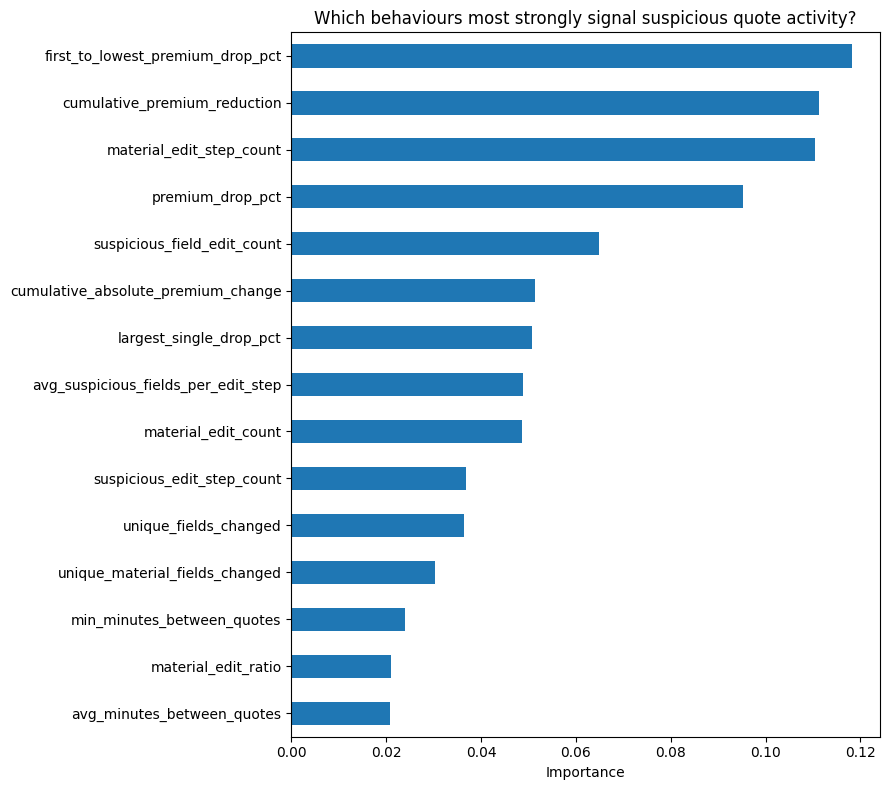

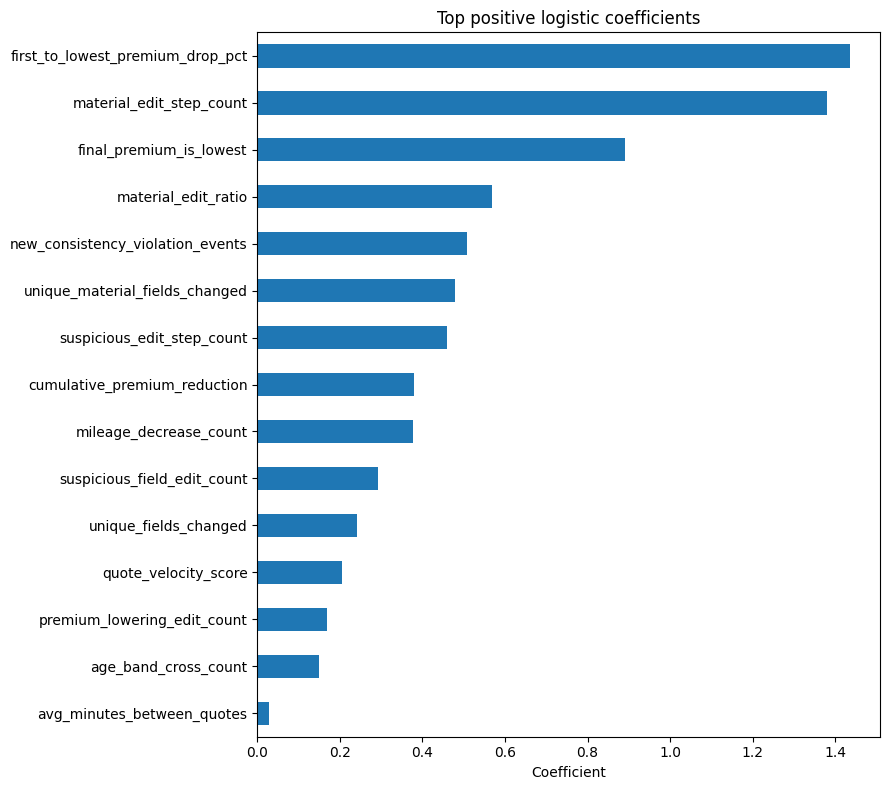

<Figure size 640x480 with 0 Axes>

In [9]:
# Examine feature importance and logistic regression coefficients to understand which behavioural signals drive predictions.

rf_interpret = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=4,
    random_state=SEED,
    n_jobs=-1
)
rf_interpret.fit(X, y)

rf_importance = pd.Series(rf_interpret.feature_importances_, index=model_features).sort_values()

plt.figure(figsize=(9, 8))
rf_importance.tail(15).plot(kind="barh")
plt.title("Which behaviours most strongly signal suspicious quote activity?")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, random_state=SEED))
])
lr_pipeline.fit(X, y)

lr_coefs = pd.Series(lr_pipeline.named_steps["lr"].coef_[0], index=model_features).sort_values()

plt.figure(figsize=(9, 8))
lr_coefs.tail(15).plot(kind="barh")
plt.title("Top positive logistic coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()
plt.tight_layout()

# **STEP 7: Case review**

In [10]:
# Inspect individual customer quote journeys to understand model behaviour, including true positives, false positives, and false negatives.

features_df = features_df.sort_values("risk_score", ascending=False).reset_index(drop=True)

print("\nTop suspicious journeys")
for cid in features_df.head(3)["customer_id"].tolist():
    review_case(cid, quotes_df, features_df)

print("\nSample false positives")
fp_ids = features_df.loc[
    (features_df["suspicious_journey_label"] == 0) & (features_df["risk_score"] >= 0.5),
    "customer_id"
].head(2).tolist()
for cid in fp_ids:
    review_case(cid, quotes_df, features_df)

print("\nSample false negatives")
fn_ids = features_df.loc[
    (features_df["suspicious_journey_label"] == 1) & (features_df["risk_score"] < 0.5),
    "customer_id"
].head(2).tolist()
for cid in fn_ids:
    review_case(cid, quotes_df, features_df)



Top suspicious journeys

Customer 662
label=1, score=0.907, action=Escalate for manual review
n_quotes=5, first_to_lowest_drop=31.59%, material_edit_count=6, suspicious_step_ratio=1.00, suspicious_field_edit_count=7, consistency_violation_count=0
 quote_number          quote_time  driver_age  driver_experience  previous_accidents  annual_mileage  premium    age_band  consistency_violation                                          changed_fields                         material_fields                      suspicious_premium_lowering_fields
            1 2026-03-04 22:51:00          58                  5                   5            25.0  1912.18 40-64_lower                      0                                                      []                                      []                                                      []
            2 2026-03-04 23:21:00          58                  5                   4            26.7  1752.11 40-64_lower                      0              

# **Step 8: Visualisations**

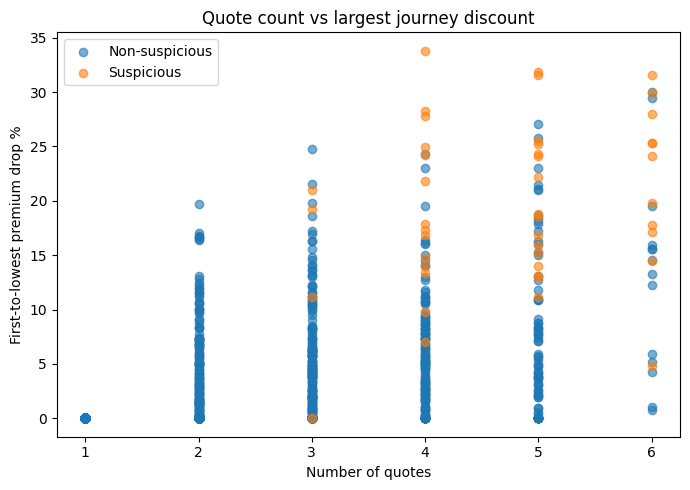

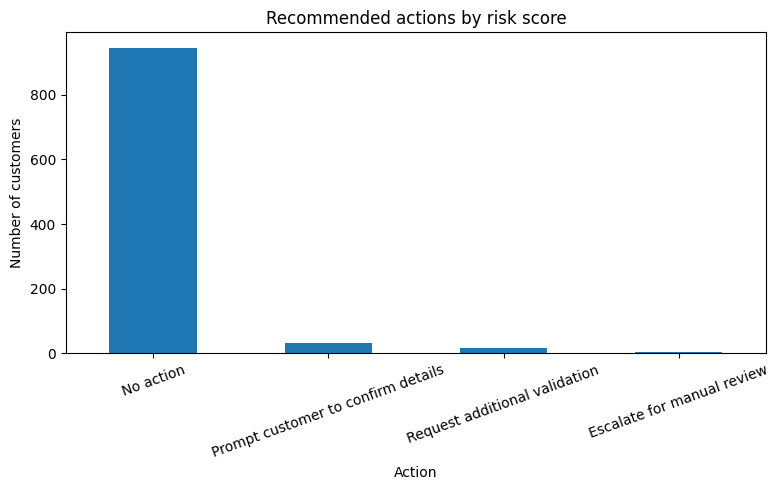

In [11]:
# Generate plots that illustrate behavioural patterns and model outputs.

plt.figure(figsize=(7, 5))
for label_value, name in [(0, "Non-suspicious"), (1, "Suspicious")]:
    subset = features_df[features_df["suspicious_journey_label"] == label_value]
    plt.scatter(
        subset["n_quotes"],
        subset["first_to_lowest_premium_drop_pct"],
        alpha=0.6,
        label=name,
    )
plt.xlabel("Number of quotes")
plt.ylabel("First-to-lowest premium drop %")
plt.title("Quote count vs largest journey discount")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
action_summary = features_df["recommended_action"].value_counts()
action_summary.plot(kind="bar")
plt.title("Recommended actions by risk score")
plt.xlabel("Action")
plt.ylabel("Number of customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# **STEP 9: Behaviour shift / drift test**


Best model performance under shifted behaviour
----------------------------------------------
              precision    recall  f1-score   support

           0      0.988     0.992     0.990       969
           1      0.704     0.613     0.655        31

    accuracy                          0.980      1000
   macro avg      0.846     0.802     0.822      1000
weighted avg      0.979     0.980     0.979      1000

Confusion matrix:
 [[961   8]
 [ 12  19]]

Top feature drift
                                     base_mean  shifted_mean  absolute_change  pct_change
max_minutes_between_quotes          202.842000    170.250000       -32.592000  -16.067678
avg_minutes_between_quotes          163.040017    132.972267       -30.067750  -18.441945
min_minutes_between_quotes          122.164000     95.839000       -26.325000  -21.548901
cumulative_absolute_premium_change  118.218790    130.005730        11.786940    9.970445
cumulative_premium_reduction         68.807370     67.573830       

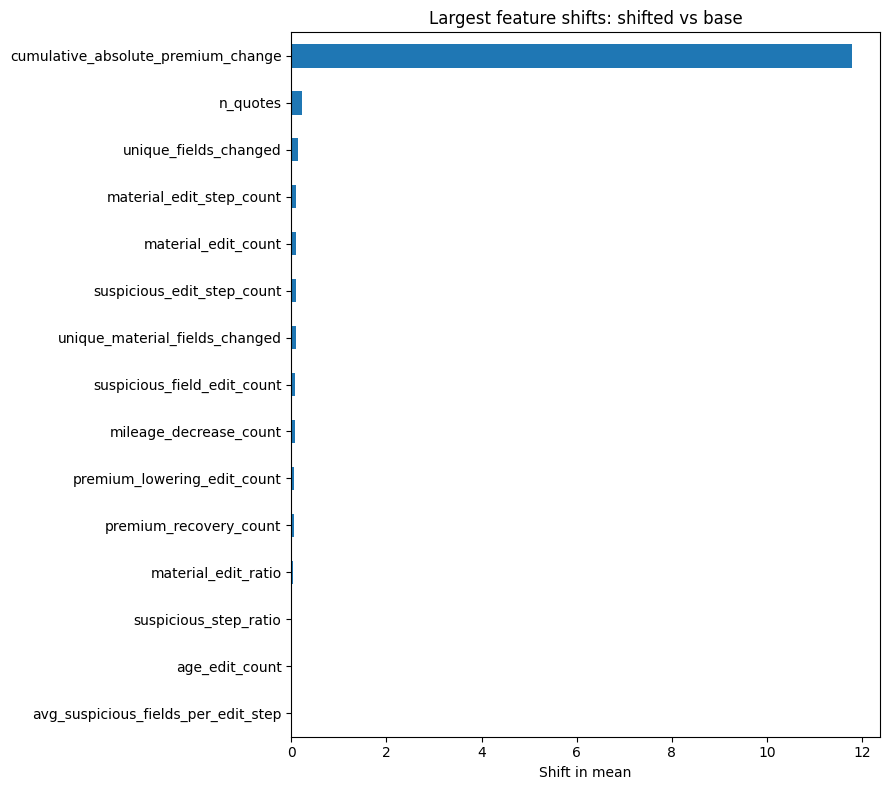

In [12]:
# Simulate a change in customer behaviour and evaluate how the trained model performs under the shifted distribution.
shifted_quotes_df = build_quotes_dataframe(df, shifted=True)
shifted_features_df = add_rule_flag(engineer_customer_features(shifted_quotes_df))

X_shifted = shifted_features_df[model_features]
y_shifted = shifted_features_df["suspicious_journey_label"]

shifted_probs = best_model.predict_proba(X_shifted)[:, 1]
shifted_pred = (shifted_probs >= 0.5).astype(int)

print_metrics(y_shifted, shifted_pred, "Best model performance under shifted behaviour")

base_means = features_df[model_features].mean()
shifted_means = shifted_features_df[model_features].mean()

drift_table = pd.DataFrame({
    "base_mean": base_means,
    "shifted_mean": shifted_means,
})
drift_table["absolute_change"] = drift_table["shifted_mean"] - drift_table["base_mean"]
drift_table["pct_change"] = (
    drift_table["absolute_change"] / drift_table["base_mean"].replace(0, np.nan)
) * 100

print("\nTop feature drift")
print(
    drift_table.reindex(
        drift_table["absolute_change"].abs().sort_values(ascending=False).index
    ).head(12).to_string()
)

plt.figure(figsize=(9, 8))
drift_table["absolute_change"].sort_values().tail(15).plot(kind="barh")
plt.title("Largest feature shifts: shifted vs base")
plt.xlabel("Shift in mean")
plt.tight_layout()
plt.show()


# **STEP 10: Candidate behavioural factor analysis**

In [13]:
# Summarise key behavioural features that differentiate suspicious and normal quote journeys and may act as pricing integrity signals.
factor_summary = features_df.groupby("suspicious_journey_label")[model_features].mean().T
factor_summary.columns = ["NonSuspicious", "Suspicious"]
factor_summary["Difference"] = factor_summary["Suspicious"] - factor_summary["NonSuspicious"]

print("\nCandidate factor summary")
print(factor_summary.sort_values("Difference", ascending=False).head(15).to_string())

rating_factor_table = pd.DataFrame({
    "rf_importance": pd.Series(rf_interpret.feature_importances_, index=model_features),
    "lr_coefficient": lr_coefs.reindex(model_features),
    "normal_mean": features_df.loc[features_df["suspicious_journey_label"] == 0, model_features].mean(),
    "suspicious_mean": features_df.loc[features_df["suspicious_journey_label"] == 1, model_features].mean(),
})
rating_factor_table["mean_difference"] = (
    rating_factor_table["suspicious_mean"] - rating_factor_table["normal_mean"]
)
rating_factor_table = rating_factor_table.sort_values(
    ["rf_importance", "mean_difference"],
    ascending=False
)

print("\nTop candidate behavioural factors")
print(rating_factor_table.head(12).to_string())


Candidate factor summary
                                    NonSuspicious  Suspicious  Difference
cumulative_absolute_premium_change     105.916168  379.307778  273.391610
cumulative_premium_reduction            58.165215  294.657556  236.492341
first_to_lowest_premium_drop_pct         3.483238   19.616386   16.133149
premium_drop_pct                         0.626416   15.194599   14.568182
largest_single_drop_pct                  3.920718   14.906012   10.985294
suspicious_field_edit_count              0.757068    4.333333    3.576265
material_edit_count                      0.527749    3.266667    2.738918
suspicious_edit_step_count               0.665969    3.022222    2.356254
n_quotes                                 2.698429    4.755556    2.057126
material_edit_step_count                 0.456545    2.466667    2.010122
unique_fields_changed                    0.993717    2.911111    1.917394
unique_material_fields_changed           0.479581    2.355556    1.875974
mileage_decr

# **STEP 11: LLM-assisted referral triage layer**

This section converts flagged suspicious quote journeys into concise case-review explanations for referral triage.

The LLM layer does not make the fraud decision. It explains why the existing behavioural model flagged a journey, using only structured evidence from the quote journey and engineered behavioural features.

The layer is built and evaluated as a small MLOps workflow:
- versioned prompts (Step 12)
- an LLM client with a deterministic fallback (Step 13)
- generation across all prompt versions (Step 14)
- automated rubric scoring (Step 15)
- a human-labelled check on the automated scorer (Step 16)
- experiment tracking with MLflow (Step 17)
- a metric-based promotion gate (Step 18)
- the final analyst referral queue (Step 19)

In [14]:
!pip install -q mlflow openai

In [15]:
import json
import mlflow
from datetime import datetime

In [16]:
# Select cases for referral explanation.
# Use high-risk cases first, then add a few false positives / false negatives for evaluation variety.

referral_cases = features_df.loc[
    features_df["risk_score"] >= 0.50
].sort_values("risk_score", ascending=False).head(20).copy()

print("Referral cases selected:", referral_cases.shape[0])
referral_cases[[
    "customer_id",
    "suspicious_journey_label",
    "risk_score",
    "recommended_action",
    "n_quotes",
    "first_to_lowest_premium_drop_pct",
    "material_edit_count",
    "suspicious_step_ratio",
    "consistency_violation_count"
]].head()

Referral cases selected: 20


,customer_id,suspicious_journey_label,risk_score,recommended_action,n_quotes,first_to_lowest_premium_drop_pct,material_edit_count,suspicious_step_ratio,consistency_violation_count
0,662,1,0.907188,Escalate for manual review,5,31.586462,6,1.0,0
1,268,1,0.905600,Escalate for manual review,6,29.962748,6,0.8,0
2,191,1,0.874850,Escalate for manual review,6,31.612960,4,0.8,0
3,407,1,0.872441,Escalate for manual review,4,27.815313,4,1.0,0
4,943,1,0.872072,Escalate for manual review,5,25.508911,4,1.0,0


In [17]:
def build_case_evidence(customer_id, quotes_df, features_df):
    feat = features_df.loc[features_df["customer_id"] == customer_id].iloc[0]
    journey = quotes_df.loc[quotes_df["customer_id"] == customer_id].copy()

    evidence = {
        "customer_id": int(customer_id),
        "risk_score": round(float(feat["risk_score"]), 3),
        "recommended_action": str(feat["recommended_action"]),
        "n_quotes": int(feat["n_quotes"]),
        "first_to_lowest_premium_drop_pct": round(float(feat["first_to_lowest_premium_drop_pct"]), 2),
        "largest_single_drop_pct": round(float(feat["largest_single_drop_pct"]), 2),
        "material_edit_count": int(feat["material_edit_count"]),
        "suspicious_field_edit_count": int(feat["suspicious_field_edit_count"]),
        "suspicious_step_ratio": round(float(feat["suspicious_step_ratio"]), 2),
        "mileage_decrease_count": int(feat["mileage_decrease_count"]),
        "accident_decrease_count": int(feat["accident_decrease_count"]),
        "experience_increase_count": int(feat["experience_increase_count"]),
        "age_band_cross_count": int(feat["age_band_cross_count"]),
        "consistency_violation_count": int(feat["consistency_violation_count"]),
        "quote_sequence": journey[[
            "quote_number",
            "driver_age",
            "driver_experience",
            "previous_accidents",
            "annual_mileage",
            "premium",
            "changed_fields",
            "suspicious_premium_lowering_fields"
        ]].to_dict(orient="records")
    }

    return evidence


sample_evidence = build_case_evidence(
    referral_cases.iloc[0]["customer_id"],
    quotes_df,
    features_df
)

print(json.dumps(sample_evidence, indent=2, default=str)[:3000])

{
  "customer_id": 662,
  "risk_score": 0.907,
  "recommended_action": "Escalate for manual review",
  "n_quotes": 5,
  "first_to_lowest_premium_drop_pct": 31.59,
  "largest_single_drop_pct": 16.4,
  "material_edit_count": 6,
  "suspicious_field_edit_count": 7,
  "suspicious_step_ratio": 1.0,
  "mileage_decrease_count": 3,
  "accident_decrease_count": 3,
  "experience_increase_count": 1,
  "age_band_cross_count": 0,
  "consistency_violation_count": 0,
  "quote_sequence": [
    {
      "quote_number": 1,
      "driver_age": 58,
      "driver_experience": 5,
      "previous_accidents": 5,
      "annual_mileage": 25.0,
      "premium": 1912.18,
      "changed_fields": [],
      "suspicious_premium_lowering_fields": []
    },
    {
      "quote_number": 2,
      "driver_age": 58,
      "driver_experience": 5,
      "previous_accidents": 4,
      "annual_mileage": 26.7,
      "premium": 1752.11,
      "changed_fields": [
        "annual_mileage",
        "previous_accidents"
      ],
      

# **STEP 12: Versioned prompt registry**

Prompts are treated as versioned artefacts rather than throwaway strings. Each version carries a creation date and a change note describing what was modified and why, so every MLflow run can be traced back to the exact prompt text that produced it.

Three versions are compared:
- **v1_basic**: minimal constraints
- **v2_grounded_concise**: hard rules added (word limit, no invented values, mention the recommended action)
- **v3_structured**: enforced REASONS / ACTION output format for analyst queue consistency

In [18]:
PROMPT_VERSIONS = {
    "v1_basic": {
        "created": "2026-06-10",
        "change_note": "Initial prompt. Minimal constraints.",
        "system": """You are assisting an insurance pricing integrity analyst.

Use only the supplied case evidence.
Write a concise referral explanation for why this quote journey was flagged.

Do not claim fraud.
Do not invent facts.
Mention the strongest behavioural reasons."""
    },

    "v2_grounded_concise": {
        "created": "2026-06-10",
        "change_note": "Added hard rules: word limit, no invented values, mention recommended action.",
        "system": """You are assisting an insurance pricing integrity analyst.

Task:
Generate a short case-review explanation for a flagged motor insurance quote journey.

Rules:
- Use only the supplied structured evidence.
- Do not claim fraud or intent.
- Do not invent values, fields, or events.
- Explain why the journey may need review.
- Keep the explanation under 90 words.
- Mention the recommended action.

Focus on:
- repeated quote attempts
- premium reduction behaviour
- material rating-factor edits
- suspicious field changes
- consistency issues"""
    },

    "v3_structured": {
        "created": "2026-06-12",
        "change_note": "Enforced fixed output format for analyst queue consistency.",
        "system": """You are assisting an insurance pricing integrity analyst.

Generate a case-review explanation for a flagged motor insurance quote journey.

Output format (exactly):
REASONS:
- <reason 1>
- <reason 2>
- <reason 3 if applicable>
ACTION: <recommended action from the evidence>

Rules:
- Use only values present in the supplied evidence. Every number you state must appear in the evidence.
- Do not claim fraud or intent. Use language like "may warrant review".
- Maximum 3 reasons, each under 20 words.
- No text before REASONS or after the ACTION line."""
    }
}

print("Prompt versions:", list(PROMPT_VERSIONS.keys()))

Prompt versions: ['v1_basic', 'v2_grounded_concise', 'v3_structured']


# **STEP 13: LLM client with deterministic fallback**

Explanations are generated using Llama 3.1 8B via the Groq API. The client includes retry logic with exponential backoff for rate-limit resilience.

If no API key is available, the layer falls back to a deterministic rule-based stub. This keeps the pipeline fully runnable without external dependencies, which matters for CI: automated test runs never call a third-party API and remain reproducible.

The API key is read from Colab Secrets or an environment variable. It is never stored in the notebook.

In [19]:
import time

LLM_MODEL = "llama-3.1-8b-instant"
LLM_MODE = "stub"  # becomes "groq" if a key is found
client = None

try:
    from google.colab import userdata
    _groq_key = userdata.get("GROQ_API_KEY")
except Exception:
    import os
    _groq_key = os.environ.get("GROQ_API_KEY")

if _groq_key:
    from openai import OpenAI
    client = OpenAI(api_key=_groq_key, base_url="https://api.groq.com/openai/v1")
    LLM_MODE = "groq"

print(f"LLM mode: {LLM_MODE}")


def generate_referral_explanation_stub(case_evidence):
    """Deterministic fallback. Also used in CI so tests never call an external API."""
    reasons = []
    if case_evidence["n_quotes"] >= 4:
        reasons.append(f"{case_evidence['n_quotes']} quote attempts were made")
    if case_evidence["first_to_lowest_premium_drop_pct"] >= 10:
        reasons.append(
            f"the premium reduced by {case_evidence['first_to_lowest_premium_drop_pct']}% from first to lowest quote"
        )
    if case_evidence["material_edit_count"] > 0:
        reasons.append(f"{case_evidence['material_edit_count']} material rating-factor edits were observed")
    if case_evidence["mileage_decrease_count"] > 0:
        reasons.append("declared mileage decreased during the journey")
    if case_evidence["accident_decrease_count"] > 0:
        reasons.append("previous accident count decreased during the journey")
    if case_evidence["experience_increase_count"] > 0:
        reasons.append("declared driving experience increased during the journey")
    if case_evidence["age_band_cross_count"] > 0:
        reasons.append("an age-band threshold crossing occurred")
    if case_evidence["consistency_violation_count"] > 0:
        reasons.append("age/experience consistency issues were detected")
    if not reasons:
        reasons.append("the model assigned an elevated risk score based on combined behavioural signals")

    return (
        f"This journey was flagged for review because {', '.join(reasons[:4])}. "
        f"The risk score is {case_evidence['risk_score']}, and the recommended action is: "
        f"{case_evidence['recommended_action']}. This does not prove fraud, but supports referral triage."
    )


def generate_referral_explanation(case_evidence, prompt_version, max_retries=3):
    """Generate an explanation. Returns dict with text, latency, token usage, and mode."""
    if LLM_MODE == "stub":
        start = time.time()
        text = generate_referral_explanation_stub(case_evidence)
        return {
            "explanation": text,
            "latency_s": round(time.time() - start, 3),
            "prompt_tokens": None,
            "completion_tokens": None,
            "llm_mode": "stub"
        }

    system_prompt = PROMPT_VERSIONS[prompt_version]["system"]
    user_prompt = "CASE EVIDENCE (JSON):\n" + json.dumps(case_evidence, default=str)

    for attempt in range(max_retries):
        try:
            start = time.time()
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.2,
                max_tokens=250
            )
            return {
                "explanation": response.choices[0].message.content.strip(),
                "latency_s": round(time.time() - start, 3),
                "prompt_tokens": response.usage.prompt_tokens,
                "completion_tokens": response.usage.completion_tokens,
                "llm_mode": "groq"
            }
        except Exception as e:
            if attempt == max_retries - 1:
                raise
            wait = 2 ** attempt * 5
            print(f"Retry {attempt + 1} after error: {e}. Waiting {wait}s.")
            time.sleep(wait)

LLM mode: groq


# **STEP 14: Generate referral explanations**

Each selected referral case is passed through every prompt version. Alongside the explanation text, the loop records latency and token usage per call, which are later logged to MLflow as operational metrics.

In [20]:
import time

LLM_MODEL = "llama-3.1-8b-instant"
LLM_MODE = "stub"  # becomes "groq" if a key is found
client = None

try:
    from google.colab import userdata
    _groq_key = userdata.get("GROQ_API_KEY")
except Exception:
    import os
    _groq_key = os.environ.get("GROQ_API_KEY")

if _groq_key:
    from openai import OpenAI
    client = OpenAI(api_key=_groq_key, base_url="https://api.groq.com/openai/v1")
    LLM_MODE = "groq"

print(f"LLM mode: {LLM_MODE}")


def generate_referral_explanation_stub(case_evidence):
    """Deterministic fallback. Also used in CI so tests never call an external API."""
    reasons = []
    if case_evidence["n_quotes"] >= 4:
        reasons.append(f"{case_evidence['n_quotes']} quote attempts were made")
    if case_evidence["first_to_lowest_premium_drop_pct"] >= 10:
        reasons.append(
            f"the premium reduced by {case_evidence['first_to_lowest_premium_drop_pct']}% from first to lowest quote"
        )
    if case_evidence["material_edit_count"] > 0:
        reasons.append(f"{case_evidence['material_edit_count']} material rating-factor edits were observed")
    if case_evidence["mileage_decrease_count"] > 0:
        reasons.append("declared mileage decreased during the journey")
    if case_evidence["accident_decrease_count"] > 0:
        reasons.append("previous accident count decreased during the journey")
    if case_evidence["experience_increase_count"] > 0:
        reasons.append("declared driving experience increased during the journey")
    if case_evidence["age_band_cross_count"] > 0:
        reasons.append("an age-band threshold crossing occurred")
    if case_evidence["consistency_violation_count"] > 0:
        reasons.append("age/experience consistency issues were detected")
    if not reasons:
        reasons.append("the model assigned an elevated risk score based on combined behavioural signals")

    return (
        f"This journey was flagged for review because {', '.join(reasons[:4])}. "
        f"The risk score is {case_evidence['risk_score']}, and the recommended action is: "
        f"{case_evidence['recommended_action']}. This does not prove fraud, but supports referral triage."
    )


def generate_referral_explanation(case_evidence, prompt_version, max_retries=3):
    """Generate an explanation. Returns dict with text, latency, token usage, and mode."""
    if LLM_MODE == "stub":
        start = time.time()
        text = generate_referral_explanation_stub(case_evidence)
        return {
            "explanation": text,
            "latency_s": round(time.time() - start, 3),
            "prompt_tokens": None,
            "completion_tokens": None,
            "llm_mode": "stub"
        }

    system_prompt = PROMPT_VERSIONS[prompt_version]["system"]
    user_prompt = "CASE EVIDENCE (JSON):\n" + json.dumps(case_evidence, default=str)

    for attempt in range(max_retries):
        try:
            start = time.time()
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.2,
                max_tokens=250
            )
            return {
                "explanation": response.choices[0].message.content.strip(),
                "latency_s": round(time.time() - start, 3),
                "prompt_tokens": response.usage.prompt_tokens,
                "completion_tokens": response.usage.completion_tokens,
                "llm_mode": "groq"
            }
        except Exception as e:
            if attempt == max_retries - 1:
                raise
            wait = 2 ** attempt * 5
            print(f"Retry {attempt + 1} after error: {e}. Waiting {wait}s.")
            time.sleep(wait)

LLM mode: groq


In [21]:
llm_outputs = []

for _, row in referral_cases.iterrows():
    customer_id = row["customer_id"]
    case_evidence = build_case_evidence(customer_id, quotes_df, features_df)

    for prompt_version in PROMPT_VERSIONS:
        result = generate_referral_explanation(case_evidence, prompt_version)
        llm_outputs.append({
            "customer_id": customer_id,
            "prompt_version": prompt_version,
            "risk_score": case_evidence["risk_score"],
            "recommended_action": case_evidence["recommended_action"],
            "explanation": result["explanation"],
            "latency_s": result["latency_s"],
            "prompt_tokens": result["prompt_tokens"],
            "completion_tokens": result["completion_tokens"],
            "llm_mode": result["llm_mode"]
        })
        total_expected = referral_cases.shape[0] * len(PROMPT_VERSIONS)
        print(f"  [{len(llm_outputs)}/{total_expected}] customer {customer_id} | {prompt_version} | {result['latency_s']}s", flush=True)

        if LLM_MODE == "groq":
            time.sleep(1.5)

llm_outputs_df = pd.DataFrame(llm_outputs)
print(f"Generated {len(llm_outputs_df)} explanations "
      f"({referral_cases.shape[0]} cases x {len(PROMPT_VERSIONS)} prompt versions, mode={LLM_MODE})")
llm_outputs_df.head()

  [1/60] customer 662 | v1_basic | 2.45s
  [2/60] customer 662 | v2_grounded_concise | 0.306s
  [3/60] customer 662 | v3_structured | 0.209s
  [4/60] customer 268 | v1_basic | 0.419s
  [5/60] customer 268 | v2_grounded_concise | 0.346s
  [6/60] customer 268 | v3_structured | 0.211s
  [7/60] customer 191 | v1_basic | 1.485s
  [8/60] customer 191 | v2_grounded_concise | 8.617s
  [9/60] customer 191 | v3_structured | 8.355s
  [10/60] customer 407 | v1_basic | 5.677s
  [11/60] customer 407 | v2_grounded_concise | 7.405s
  [12/60] customer 407 | v3_structured | 5.31s
  [13/60] customer 943 | v1_basic | 5.654s
  [14/60] customer 943 | v2_grounded_concise | 7.579s
  [15/60] customer 943 | v3_structured | 5.403s
  [16/60] customer 863 | v1_basic | 6.668s
  [17/60] customer 863 | v2_grounded_concise | 7.44s
  [18/60] customer 863 | v3_structured | 7.414s
  [19/60] customer 907 | v1_basic | 8.629s
  [20/60] customer 907 | v2_grounded_concise | 7.797s
  [21/60] customer 907 | v3_structured | 5.37

,customer_id,prompt_version,risk_score,recommended_action,explanation,latency_s,prompt_tokens,completion_tokens,llm_mode
0,662,v1_basic,0.907,Escalate for manual review,Referral Explanation:\n\nThis quote journey ha...,2.450,635,242,groq
1,662,v2_grounded_concise,0.907,Escalate for manual review,**Case Review Explanation**\n\nThis motor insu...,0.306,694,93,groq
2,662,v3_structured,0.907,Escalate for manual review,REASONS:\n- The customer received 5 quotes wit...,0.209,713,69,groq
3,268,v1_basic,0.906,Escalate for manual review,Referral Explanation:\n\nThis quote journey wa...,0.419,717,175,groq
4,268,v2_grounded_concise,0.906,Escalate for manual review,**Case Review Explanation**\n\nCustomer ID: 26...,0.346,776,128,groq


# **STEP 15: Automated rubric evaluation**

Every generated explanation is scored against rubric criteria:

- **Groundedness**: the output must not claim fraud or intent
- **Factual correctness**: every number stated in the output must exist in the supplied case evidence (numeric claim verification catches hallucinated values)
- **Conciseness**: word-limit compliance
- **Format compliance** (v3 only): the enforced REASONS / ACTION structure is checked programmatically

Automated checks catch mechanical failures cheaply and consistently across all outputs.

In [22]:
import re

# Expanded after Step 16B: the original list missed intent language that
# human review flagged (e.g. "deliberate attempt to manipulate", "intentionally").
# Added the words/stems below, which lifts groundedness agreement from 68% to 100%.
BANNED_PHRASES = [
    "fraud confirmed", "fraudulent", "intentional fraud", "deliberately lied",
    "committed fraud", "is lying", "dishonest customer",
    "deliberate", "intentional", "manipulat", "taking advantage", "trying to manipulate"
]


def extract_numbers(text):
    return [float(x) for x in re.findall(r"-?\d+\.?\d*", text)]


def evidence_number_set(case_evidence):
    nums = set()

    def collect(value):
        if isinstance(value, bool):
            return
        if isinstance(value, (int, float)):
            nums.add(round(float(value), 2))
            nums.add(round(float(value), 0))
        elif isinstance(value, dict):
            for v in value.values():
                collect(v)
        elif isinstance(value, list):
            for v in value:
                collect(v)

    collect(case_evidence)
    return nums


def score_groundedness(text):
    return 0 if any(term in text.lower() for term in BANNED_PHRASES) else 1


def score_factual_correctness(text, case_evidence):
    """Every number the model states must appear somewhere in the evidence."""
    claimed = extract_numbers(text)
    if not claimed:
        return 1
    valid = evidence_number_set(case_evidence)
    for n in claimed:
        if round(n, 2) not in valid and round(n, 0) not in valid:
            return 0
    return 1


def score_conciseness(text, max_words=90):
    return 1 if len(text.split()) <= max_words else 0


def score_format_compliance(text, prompt_version):
    if prompt_version != "v3_structured":
        return None
    has_reasons = text.strip().startswith("REASONS:")
    has_action = "ACTION:" in text
    bullet_count = text.count("\n-") + text.count("\n -")
    return 1 if (has_reasons and has_action and 1 <= bullet_count <= 3) else 0


eval_rows = []
for _, row in llm_outputs_df.iterrows():
    case_evidence = build_case_evidence(row["customer_id"], quotes_df, features_df)
    eval_rows.append({
        **row.to_dict(),
        "groundedness": score_groundedness(row["explanation"]),
        "factual_correctness": score_factual_correctness(row["explanation"], case_evidence),
        "conciseness": score_conciseness(row["explanation"]),
        "format_compliance": score_format_compliance(row["explanation"], row["prompt_version"])
    })

eval_df = pd.DataFrame(eval_rows)
eval_df["overall_rubric_score"] = eval_df[
    ["groundedness", "factual_correctness", "conciseness"]
].mean(axis=1)

eval_df.head()

,customer_id,prompt_version,risk_score,recommended_action,explanation,latency_s,prompt_tokens,completion_tokens,llm_mode,groundedness,factual_correctness,conciseness,format_compliance,overall_rubric_score
0,662,v1_basic,0.907,Escalate for manual review,Referral Explanation:\n\nThis quote journey ha...,2.450,635,242,groq,0,1,0,NaN,0.333333
1,662,v2_grounded_concise,0.907,Escalate for manual review,**Case Review Explanation**\n\nThis motor insu...,0.306,694,93,groq,1,1,1,NaN,1.000000
2,662,v3_structured,0.907,Escalate for manual review,REASONS:\n- The customer received 5 quotes wit...,0.209,713,69,groq,1,1,1,1.0,1.000000
3,268,v1_basic,0.906,Escalate for manual review,Referral Explanation:\n\nThis quote journey wa...,0.419,717,175,groq,0,1,0,NaN,0.333333
4,268,v2_grounded_concise,0.906,Escalate for manual review,**Case Review Explanation**\n\nCustomer ID: 26...,0.346,776,128,groq,1,1,0,NaN,0.666667


# **STEP 16: Human-labelled evaluation set**

Automated scores cannot catch subtle failures such as misleading emphasis, implied intent, or technically-present-but-weak reasons. A labelling sheet is exported, scored manually, and re-imported.

Agreement between automated and human scores validates the automated scorer: high agreement means the cheap automated checks can be trusted as a first-pass quality gate.

In [23]:
label_sheet = eval_df[[
    "customer_id", "prompt_version", "explanation"
]].copy()
label_sheet["human_groundedness"] = ""
label_sheet["human_factual_correctness"] = ""
label_sheet["human_conciseness"] = ""
label_sheet["human_notes"] = ""

label_sheet.to_csv("human_eval_sheet.csv", index=False)
print(f"Exported human_eval_sheet.csv with {len(label_sheet)} rows.")
print("Fill the human_* columns (1 or 0) for at least 30 rows, save as human_eval_labelled.csv, re-upload, then run the next cell.")

Exported human_eval_sheet.csv with 60 rows.
Fill the human_* columns (1 or 0) for at least 30 rows, save as human_eval_labelled.csv, re-upload, then run the next cell.


# **STEP 16B: Auto-scorer vs human label agreement**

Human labels are merged with the automated rubric scores from Step 15 to measure agreement.

High agreement validates that the automated checks can be trusted as a first-pass quality gate. Disagreements are informative: they reveal gaps in the automated scorer that can be closed by expanding the banned-phrase list or tightening the numeric verification logic.

In [24]:
human_df = pd.read_csv("human_eval_labelled.csv")
human_df = human_df.dropna(subset=["human_groundedness"])
human_df["human_groundedness"] = human_df["human_groundedness"].astype(int)
human_df["human_factual_correctness"] = human_df["human_factual_correctness"].astype(int)
human_df["human_conciseness"] = human_df["human_conciseness"].astype(int)

merged = eval_df.merge(
    human_df[["customer_id", "prompt_version",
              "human_groundedness", "human_factual_correctness", "human_conciseness"]],
    on=["customer_id", "prompt_version"]
)

print(f"Labelled rows: {len(merged)}")
print()
for metric in ["groundedness", "factual_correctness", "conciseness"]:
    agreement = (merged[metric] == merged[f"human_{metric}"]).mean()
    print(f"{metric}: auto vs human agreement = {agreement:.1%} ({int(agreement*len(merged))}/{len(merged)} rows)")

Labelled rows: 60

groundedness: auto vs human agreement = 91.7% (55/60 rows)
factual_correctness: auto vs human agreement = 81.7% (49/60 rows)
conciseness: auto vs human agreement = 88.3% (53/60 rows)


# **STEP 17: MLflow experiment tracking**

Each prompt version is logged as a separate MLflow run with full traceability:

- the exact prompt text as an artifact
- model configuration (model name, temperature, LLM mode)
- rubric metrics (groundedness, factual correctness, conciseness, format compliance)
- operational metrics (latency, completion tokens)
- the full evaluation outputs as a CSV artifact

This makes every prompt iteration comparable and reproducible across runs.

In [25]:
mlflow.set_experiment("quote_manipulation_llm_triage")

for prompt_version, group in eval_df.groupby("prompt_version"):
    run_name = f"triage_{prompt_version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("prompt_version", prompt_version)
        mlflow.log_param("prompt_change_note", PROMPT_VERSIONS[prompt_version]["change_note"])
        mlflow.log_param("llm_mode", group["llm_mode"].iloc[0])
        mlflow.log_param("llm_model", LLM_MODEL if LLM_MODE == "groq" else "stub")
        mlflow.log_param("temperature", 0.2)
        mlflow.log_param("num_eval_cases", len(group))

        mlflow.log_metric("groundedness_mean", group["groundedness"].mean())
        mlflow.log_metric("factual_correctness_mean", group["factual_correctness"].mean())
        mlflow.log_metric("conciseness_mean", group["conciseness"].mean())
        mlflow.log_metric("overall_rubric_score_mean", group["overall_rubric_score"].mean())
        if group["format_compliance"].notna().any():
            mlflow.log_metric("format_compliance_mean", group["format_compliance"].mean())
        if group["latency_s"].notna().any():
            mlflow.log_metric("latency_s_mean", group["latency_s"].mean())
        if group["completion_tokens"].notna().any():
            mlflow.log_metric("completion_tokens_mean", group["completion_tokens"].mean())

        prompt_path = f"prompt_{prompt_version}.txt"
        with open(prompt_path, "w") as f:
            f.write(PROMPT_VERSIONS[prompt_version]["system"])
        mlflow.log_artifact(prompt_path)

        output_path = f"llm_triage_eval_{prompt_version}.csv"
        group.to_csv(output_path, index=False)
        mlflow.log_artifact(output_path)

print("Logged all prompt versions to MLflow.")

Logged all prompt versions to MLflow.


# **STEP 18: Prompt promotion gate**

A prompt version is promotable only if it clears minimum quality thresholds (perfect groundedness, 90%+ factual correctness, 85%+ conciseness). The best promotable version is written to `promoted_prompt.json`, the artifact a downstream service or CI quality gate would consume.

This mirrors how model or prompt promotion works in a production MLOps workflow: nothing is deployed on vibes, only on metrics clearing a gate.

In [26]:
THRESHOLDS = {
    "groundedness_mean": 1.0,
    "factual_correctness_mean": 0.90,
    "conciseness_mean": 0.85
}

summary = eval_df.groupby("prompt_version").agg(
    groundedness_mean=("groundedness", "mean"),
    factual_correctness_mean=("factual_correctness", "mean"),
    conciseness_mean=("conciseness", "mean"),
    overall_rubric_score_mean=("overall_rubric_score", "mean")
).reset_index()

summary["promotable"] = (
    (summary["groundedness_mean"] >= THRESHOLDS["groundedness_mean"]) &
    (summary["factual_correctness_mean"] >= THRESHOLDS["factual_correctness_mean"]) &
    (summary["conciseness_mean"] >= THRESHOLDS["conciseness_mean"])
)

print(summary.to_string(index=False))

promotable = summary[summary["promotable"]].sort_values("overall_rubric_score_mean", ascending=False)

if promotable.empty:
    print("\nNo prompt version meets promotion thresholds. Iterate before deployment.")
else:
    best = promotable.iloc[0]["prompt_version"]
    with open("promoted_prompt.json", "w") as f:
        json.dump({
            "promoted_version": best,
            "promoted_at": datetime.now().isoformat(),
            "thresholds": THRESHOLDS,
            "metrics": promotable.iloc[0].drop("prompt_version").to_dict()
        }, f, indent=2, default=str)
    print(f"\nPromoted prompt version: {best} (written to promoted_prompt.json)")

     prompt_version  groundedness_mean  factual_correctness_mean  conciseness_mean  overall_rubric_score_mean  promotable
           v1_basic                0.1                      0.75               0.0                   0.283333       False
v2_grounded_concise                1.0                      0.95               0.8                   0.916667       False
      v3_structured                1.0                      1.00               1.0                   1.000000        True

Promoted prompt version: v3_structured (written to promoted_prompt.json)


# **STEP 19: Analyst referral queue**

The final artifact a pricing integrity team would actually consume: flagged cases ranked by risk score, each with the promoted prompt's explanation attached. This closes the loop from detection model to LLM triage to operational output.

In [27]:
with open("promoted_prompt.json") as f:
    promoted_version = json.load(f)["promoted_version"]

referral_queue = eval_df[eval_df["prompt_version"] == promoted_version][[
    "customer_id", "risk_score", "recommended_action", "explanation"
]].sort_values("risk_score", ascending=False).reset_index(drop=True)

referral_queue.insert(0, "queue_position", referral_queue.index + 1)
referral_queue.to_csv("referral_queue.csv", index=False)

print(f"Referral queue built with promoted prompt '{promoted_version}': {len(referral_queue)} cases.")
referral_queue.head(10)

Referral queue built with promoted prompt 'v3_structured': 20 cases.


,queue_position,customer_id,risk_score,recommended_action,explanation
0,1,662,0.907,Escalate for manual review,REASONS:\n- The customer received 5 quotes wit...
1,2,268,0.906,Escalate for manual review,REASONS:\n- The customer had 9 suspicious fiel...
2,3,191,0.875,Escalate for manual review,REASONS:\n- The customer had a high risk score...
3,4,407,0.872,Escalate for manual review,REASONS:\n- The customer received 4 quotes wit...
4,5,943,0.872,Escalate for manual review,REASONS:\n- The customer's risk score is high ...
5,6,863,0.867,Escalate for manual review,REASONS:\n- The customer's risk score is high ...
6,7,907,0.800,Request additional validation,REASONS:\n- The customer received 6 quotes wit...
7,8,1000,0.768,Request additional validation,REASONS:\n- The customer has a high risk score...
8,9,117,0.758,Request additional validation,"REASONS:\n- The customer made 4 quotes, with a..."
9,10,958,0.745,Request additional validation,REASONS:\n- The customer made 6 quotes with a ...
